<a href="https://colab.research.google.com/github/miso-20/ESSA/blob/main/OB_0911_%EB%B9%84%EC%A7%80%EB%8F%84%ED%95%99%EC%8A%B5_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **| 비지도 학습 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch09 앙상블 학습과 랜덤 포레스트 연습문제 3, 5, 8, 10번
- 이론적 지식을 묻는 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

In [1]:
# import libraries
import numpy as np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### **1. k-평균을 사용할 때 적절한 클러스터 개수를 선택할 수 있는 두 가지 기법을 설명하세요.**
___



- 엘보우 방법 (Elbow Method): 클러스터 개수(k)를 1부터 늘려가면서 모델을 훈련시키고 각 k에 대한 이너셔(Inertia, 클러스터 내 오차 제곱합)를 그래프로 그리는 기법. k가 증가함에 따라 이너셔는 감소하는데, 감소 속도가 둔해지며 그래프가 꺾이는 지점(엘보우, 팔꿈치 모양)의 k를 최적의 클러스터 개수로 선택

- 실루엣 점수 (Silhouette Score) 및 실루엣 다이어그램 분석: 모든 샘플에 대한 실루엣 계수의 평균을 계산하는 방법. 실루엣 계수는 -1에서 +1 사이의 값을 가지며, +1에 가까울수록 샘플이 자신이 속한 클러스터의 중심에 가깝고 다른 클러스터와는 멀리 떨어져 있다는 의미. k를 변경해가며 평균 실루엣 점수가 가장 높은 k를 찾거나, 실루엣 다이어그램(각 클러스터의 실루엣 계수 분포를 시각화한 그래프)을 그려 클러스터 간 두께가 균일하고 점수가 높은 k를 선택

### **2. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘 두 개를 말해보세요. 밀도가 높은 지역을 찾는 군집 알고리즘 두 개는 무엇인가요?**
___


대규모 데이터셋으로 확장할 수 있는 군집 알고리즘 (빠르고 메모리 효율적인 알고리즘):

- 미니배치 K-평균 (Mini-batch K-Means)

- BIRCH (균형 반복적 환원 및 군집화)


밀도가 높은 지역을 찾는 군집 알고리즘 (임의의 모양을 가진 클러스터를 찾는 데 유리한 알고리즘):

- DBSCAN (밀도 기반 공간 군집화)

- 평균 이동 (Mean-Shift)

### **3. 가우시안 혼합이 무엇인가요? 어떤 작업에 사용할 수 있나요?**
___


가우시안 혼합 (GMM, Gaussian Mixture Model): 데이터 셋이 파라미터가 알려지지 않은 여러 개의 가우시안 분포(정규 분포)가 혼합되어 생성되었다고 가정하는 확률 모델이다. 즉, 데이터가 타원형 모양의 여러 클러스터 그룹으로 이루어져 있다고 보고, 각 데이터가 어떤 가우시안 분포에서 나왔을 확률을 계산하는 방식이다.

주요 활용 작업:

- 밀도 추정 (Density Estimation): 시스템이나 프로세스를 모델링하여 새로운 데이터가 발생할 확률 밀도를 추정

- 소프트 군집 (Soft Clustering): 하드 군집(k-평균처럼 하나의 클러스터에만 할당)과 달리, 특정 데이터 샘플이 각 클러스터에 속할 확률(Probability)을 추정하여 군집화함

- 이상치 탐지 (Anomaly Detection): 가우시안 분포 상에서 밀도가 매우 낮은 지역(확률이 아주 낮은 지역)에 위치한 데이터를 이상치나 결함으로 판별하는 데 유용하게 쓰임

### **4. 다음 단계를 따라 올리베티 얼굴 데이터셋을 군집해보자..**
___
전통적인 올리베티 얼굴 데이터셋은 64 X 64 픽셀 크기의 흑백 얼굴 이미지 400개를 가지고 있습니다. 사람 40명의 사진을 10장씩 찍은 것인데, 각 이미지는 4096 크기의 1D 벡터로 펼쳐져 있습니다.

#### **STEP 1. 아래 코드를 실행하여 데이터셋을 불러오세요.**

In [4]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

X = olivetti.data
y = olivetti.target

####  **STEP 2. 데이터셋을 훈련 세트, 검증 세트, 테스트 세트로 나누세요.**
해당 데이터셋은 매우 작으므로, `StratifiedShuffleSplit` 함수를 이용하여, 계층적 샘플링으로 각 세트에 동일한 사람의 얼굴이 고루 섞이도록 하세요.

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

####  **STEP 3. 속도를 높이기 위해 각 학습/검증/테스트 피처 데이터셋에 PCA을 적용하여 데이터의 차원을 줄이세요.**
- `n_componets = 0.99`로 설정합니다.

In [6]:
strat_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 1차 분할: 전체 데이터(400개)를 '훈련+검증 세트(320개, 80%)'와 '테스트 세트(80개, 20%)'로 분할
for train_valid_idx, test_idx in strat_split.split(X, y):
    X_train_valid = X[train_valid_idx]
    y_train_valid = y[train_valid_idx]
    X_test = X[test_idx]
    y_test = y[test_idx]

# 2차 분할: '훈련+검증 세트(320개)'를 다시 '훈련 세트(240개, 75%)'와 '검증 세트(80개, 25%)'로 분할
strat_split_val = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

for train_idx, valid_idx in strat_split_val.split(X_train_valid, y_train_valid):
    X_train = X_train_valid[train_idx]
    y_train = y_train_valid[train_idx]
    X_valid = X_train_valid[valid_idx]
    y_valid = y_train_valid[valid_idx]

####  **STEP 4. 교재에서 다룬 방법을 사용하여 적절한 클러스터 개수를 찾고 k-평균을 사용해 이미지를 군집해보세요.**

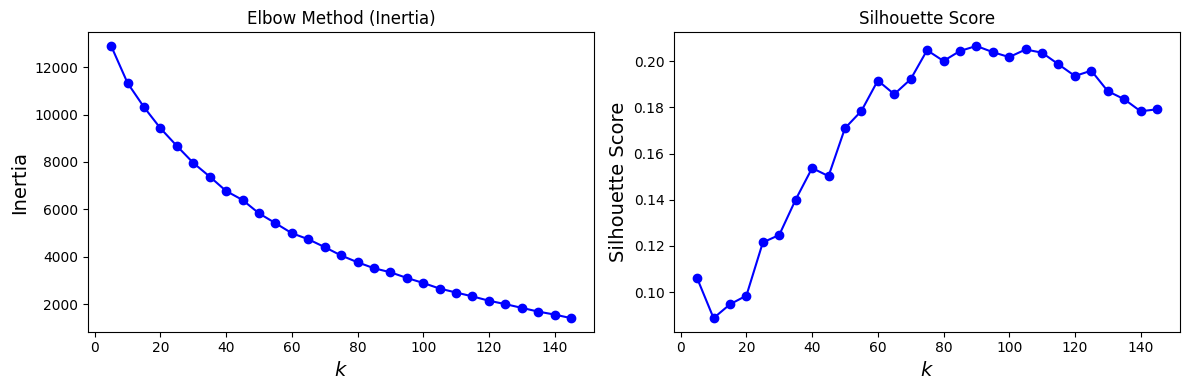

가장 높은 실루엣 점수를 가진 최적의 클러스터 개수(k): 90


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# 탐색할 클러스터 개수(k) 범위 설정 (5부터 145까지 5씩 증가)
k_range = range(5, 150, 5)
kmeans_per_k = []

# 각 k마다 K-평균 모델을 훈련하고 저장
for k in k_range:
    # n_init="auto" 혹은 10 지정 시 향후 버전의 경고를 방지
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    kmeans_per_k.append(kmeans)

# 각 모델의 이너셔와 실루엣 점수 계산
inertias = [model.inertia_ for model in kmeans_per_k]
silhouette_scores = [silhouette_score(X_train, model.labels_) for model in kmeans_per_k]

# 결과 시각화
plt.figure(figsize=(12, 4))

# 엘보우 방법 (이너셔) 그래프
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.title("Elbow Method (Inertia)")

# 실루엣 점수 그래프
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)
plt.title("Silhouette Score")

plt.tight_layout()
plt.show()

# 실루엣 점수가 가장 높은 최적의 k 찾기 및 최종 군집화
best_index = np.argmax(silhouette_scores)
best_k = k_range[best_index]
print(f"가장 높은 실루엣 점수를 가진 최적의 클러스터 개수(k): {best_k}")

# 최적의 k로 학습된 최종 K-평균 모델
best_model = kmeans_per_k[best_index]

# 최종 군집 결과 (클러스터 레이블)
final_labels = best_model.labels_

####  **STEP 5. 아래 `plot_faces` 함수를 이용하여, 클러스터를 시각화하고, 각 클러스터에 비슷한 얼굴이 들어있는지 확인해보세요.**

In [8]:
# plot_faces 함수
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()


=============== 클러스터 0 ===============


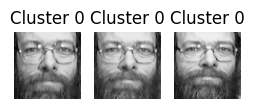


=============== 클러스터 1 ===============


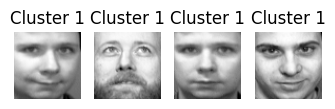


=============== 클러스터 2 ===============


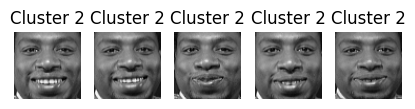


=============== 클러스터 3 ===============


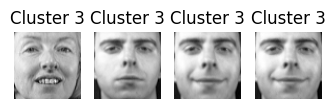


=============== 클러스터 4 ===============


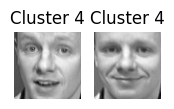

In [9]:
# 확인을 위해 임의로 5개의 클러스터(0번~4번)를 시각화
for cluster_id in range(5):
    # 현재 클러스터(cluster_id)에 속한 이미지들의 인덱스를 추출
    in_cluster = (best_model.labels_ == cluster_id)

    # 해당 클러스터로 분류된 얼굴 이미지들만 가져옴
    cluster_faces = X_train[in_cluster]

    # 해당 클러스터에 이미지가 없을 경우 건너뜀
    if len(cluster_faces) == 0:
        continue

    # 시각화할 때 각 이미지 위에 띄울 텍스트 리스트 생성
    cluster_labels = [f"Cluster {cluster_id}"] * len(cluster_faces)

    print(f"\n{'='*15} 클러스터 {cluster_id} {'='*15}")
    # 함수 호출하여 그리기
    plot_faces(cluster_faces, cluster_labels)